# 191180041 Ayben Gülnar

###### Not: Diğer ödev dosyasında da farklı bir şekilde var. Tam emin olamadım ikisini de göndermek istedim. :)

In [1]:
import numpy as np # linear algebra
import pandas as pd # d

In [2]:
data=pd.read_csv("dataset.csv")

In [3]:
data.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


[Text(0.5, 0, 'Date'), Text(0, 0.5, 'Total Number of Items Sold')]

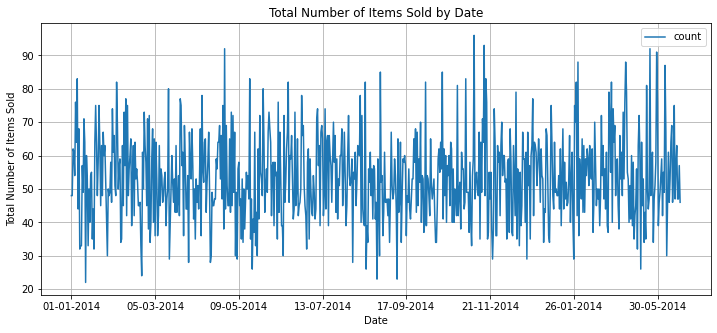

In [4]:
data.groupby(['Date'])['itemDescription'].agg(['count']).plot(figsize=(12,5), grid=True, title="Total Number of Items Sold by Date").set(xlabel="Date", ylabel="Total Number of Items Sold")

In [5]:
d=data.set_index(['Date'])


In [6]:
d

,Member_number,itemDescription
Date,,
21-07-2015,1808,tropical fruit
05-01-2015,2552,whole milk
19-09-2015,2300,pip fruit
12-12-2015,1187,other vegetables
01-02-2015,3037,whole milk
...,...,...
08-10-2014,4471,sliced cheese
23-02-2014,2022,candy
16-04-2014,1097,cake bar


In [7]:
d.index=pd.to_datetime(d.index)

C:\Users\ayben\anaconda3\lib\site-packages\pandas\core\tools\datetimes.py:1056: UserWarning: Parsing '21-07-2015' in DD/MM/YYYY format. Provide format or specify infer_datetime_format=True for consistent parsing.
  cache_array = _maybe_cache(arg, format, cache, convert_listlike)
C:\Users\ayben\anaconda3\lib\site-packages\pandas\core\tools\datetimes.py:1056: UserWarning: Parsing '19-09-2015' in DD/MM/YYYY format. Provide format or specify infer_datetime_format=True for consistent parsing.
  cache_array = _maybe_cache(arg, format, cache, convert_listlike)
C:\Users\ayben\anaconda3\lib\site-packages\pandas\core\tools\datetimes.py:1056: UserWarning: Parsing '14-02-2015' in DD/MM/YYYY format. Provide format or specify infer_datetime_format=True for consistent parsing.
  cache_array = _maybe_cache(arg, format, cache, convert_listlike)
C:\Users\ayben\anaconda3\lib\site-packages\pandas\core\tools\datetimes.py:1056: UserWarning: Parsing '23-12-2015' in DD/MM/YYYY format. Provide format or specif

In [8]:
total_items = len(d)
total_days = len(np.unique(d.index.date))
total_months = len(np.unique(d.index.month))
average_items = total_items / total_days
unique_items = d.itemDescription.unique().size

print("There are {} unique items sold ".format(unique_items))
print("Total {} items sold in {} days throughout {} months".format(total_items, total_days, total_months))
print("With an average of {} items sold daily".format(average_items))

There are 167 unique items sold 
Total 38765 items sold in 728 days throughout 12 months
With an average of 53.24862637362637 items sold daily


[Text(0.5, 0, 'Date'), Text(0, 0.5, 'Total Number of Items Sold')]

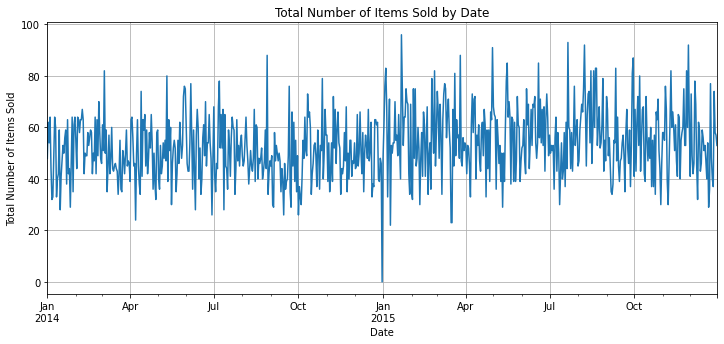

In [9]:
d.resample("D")['itemDescription'].count().plot(figsize=(12,5), grid=True, title="Total Number of Items Sold by Date").set(xlabel="Date", ylabel="Total Number of Items Sold")

[Text(0.5, 0, 'Date'), Text(0, 0.5, 'Total Number of Items Sold')]

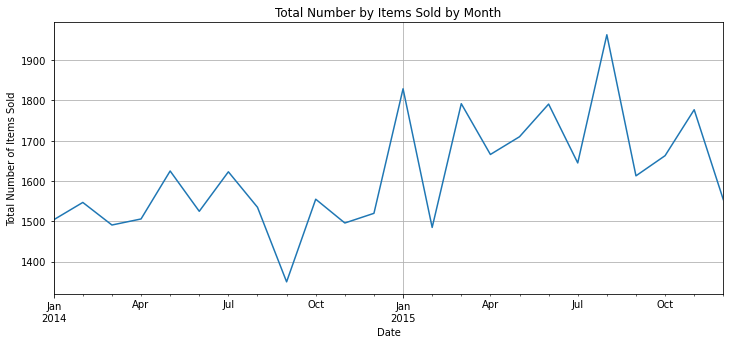

In [10]:
d.resample("M")['itemDescription'].count().plot(figsize=(12,5), grid=True, title="Total Number by Items Sold by Month").set(xlabel="Date", ylabel="Total Number of Items Sold")

In [11]:
d["Hour"] = d.index.hour
d["Weekday"] = d.index.weekday + 1

d.head(10)

,Member_number,itemDescription,Hour,Weekday
Date,,,,
2015-07-21,1808,tropical fruit,0,2
2015-05-01,2552,whole milk,0,5
2015-09-19,2300,pip fruit,0,6
2015-12-12,1187,other vegetables,0,6
2015-01-02,3037,whole milk,0,5
2015-02-14,4941,rolls/buns,0,6
2015-08-05,4501,other vegetables,0,3
2015-12-23,3803,pot plants,0,3
2015-03-20,2762,whole milk,0,5


In [12]:
data['itemDescription'].value_counts()


whole milk               2502
other vegetables         1898
rolls/buns               1716
soda                     1514
yogurt                   1334
                         ... 
rubbing alcohol             5
bags                        4
baby cosmetics              3
kitchen utensil             1
preservation products       1
Name: itemDescription, Length: 167, dtype: int64

# 1. Yaygın öğeler/sık satılan ürünler (frequent itemsets problem) problemini çözen bir Brute-Force yaklaşımı geliştiriniz.

In [13]:
df=data.groupby(['Member_number','Date'])['itemDescription'].apply(sum)
df

Member_number  Date      
1000           15-03-2015           sausagewhole milksemi-finished breadyogurt
               24-06-2014                          whole milkpastrysalty snack
               24-07-2015                           canned beermisc. beverages
               25-11-2015                              sausagehygiene articles
               27-05-2015                               sodapickled vegetables
                                                   ...                        
4999           24-01-2015    tropical fruitberriesother vegetablesyogurtkit...
               26-12-2015                                   bottled waterherbs
5000           09-03-2014                          fruit/vegetable juiceonions
               10-02-2015               sodaroot vegetablessemi-finished bread
               16-11-2014                         bottled beerother vegetables
Name: itemDescription, Length: 14963, dtype: object

In [14]:
pd.set_option('display.max_colwidth', -1)


C:\Users\ayben\AppData\Local\Temp\ipykernel_13028\2932368685.py:1: FutureWarning: Passing a negative integer is deprecated in version 1.0 and will not be supported in future version. Instead, use None to not limit the column width.
  pd.set_option('display.max_colwidth', -1)


In [15]:
transactions = [a[1]['itemDescription'].tolist() for a in list(data.groupby(['Member_number','Date']))]

In [16]:
transactions


[['sausage', 'whole milk', 'semi-finished bread', 'yogurt'],
 ['whole milk', 'pastry', 'salty snack'],
 ['canned beer', 'misc. beverages'],
 ['sausage', 'hygiene articles'],
 ['soda', 'pickled vegetables'],
 ['frankfurter', 'curd'],
 ['sausage', 'whole milk', 'rolls/buns'],
 ['whole milk', 'soda'],
 ['beef', 'white bread'],
 ['frankfurter', 'soda', 'whipped/sour cream'],
 ['frozen vegetables', 'other vegetables'],
 ['butter', 'whole milk'],
 ['tropical fruit', 'sugar'],
 ['butter milk', 'specialty chocolate'],
 ['sausage', 'rolls/buns'],
 ['root vegetables', 'detergent'],
 ['frozen meals', 'dental care'],
 ['rolls/buns', 'rolls/buns'],
 ['dish cleaner', 'cling film/bags'],
 ['canned beer', 'frozen fish'],
 ['other vegetables', 'hygiene articles'],
 ['pip fruit', 'whole milk', 'tropical fruit'],
 ['rolls/buns', 'red/blush wine', 'chocolate'],
 ['other vegetables', 'shopping bags'],
 ['whole milk', 'chocolate', 'packaged fruit/vegetables', 'rolls/buns'],
 ['root vegetables', 'whole milk'

In [17]:
pip install mlxtend

Note: you may need to restart the kernel to use updated packages.


In [18]:
from mlxtend.preprocessing import TransactionEncoder

In [19]:
te = TransactionEncoder()


In [20]:
te_ary = te.fit(transactions).transform(transactions)


In [21]:
te.columns_


['Instant food products',
 'UHT-milk',
 'abrasive cleaner',
 'artif. sweetener',
 'baby cosmetics',
 'bags',
 'baking powder',
 'bathroom cleaner',
 'beef',
 'berries',
 'beverages',
 'bottled beer',
 'bottled water',
 'brandy',
 'brown bread',
 'butter',
 'butter milk',
 'cake bar',
 'candles',
 'candy',
 'canned beer',
 'canned fish',
 'canned fruit',
 'canned vegetables',
 'cat food',
 'cereals',
 'chewing gum',
 'chicken',
 'chocolate',
 'chocolate marshmallow',
 'citrus fruit',
 'cleaner',
 'cling film/bags',
 'cocoa drinks',
 'coffee',
 'condensed milk',
 'cooking chocolate',
 'cookware',
 'cream',
 'cream cheese ',
 'curd',
 'curd cheese',
 'decalcifier',
 'dental care',
 'dessert',
 'detergent',
 'dish cleaner',
 'dishes',
 'dog food',
 'domestic eggs',
 'female sanitary products',
 'finished products',
 'fish',
 'flour',
 'flower (seeds)',
 'flower soil/fertilizer',
 'frankfurter',
 'frozen chicken',
 'frozen dessert',
 'frozen fish',
 'frozen fruits',
 'frozen meals',
 'froze

In [22]:
transactions = pd.DataFrame(te_ary, columns=te.columns_)
pf = transactions.describe()

Creating a new DataFrame transactions from an array te_ary with columns from a DataFrame te, and then it is calculating some basic statistics of the new DataFrame and storing it in a new DataFrame pf.

In [23]:
pf

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
count,14963,14963,14963,14963,14963,14963,14963,14963,14963,14963,...,14963,14963,14963,14963,14963,14963,14963,14963,14963,14963
unique,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
top,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
freq,14903,14643,14941,14934,14960,14959,14842,14946,14455,14637,...,14883,14912,14686,14309,14955,14604,14788,12600,13678,14903


In [24]:
pf.iloc[0]-pf.iloc[3]


Instant food products    60  
UHT-milk                 320 
abrasive cleaner         22  
artif. sweetener         29  
baby cosmetics           3   
                        ..   
white bread              359 
white wine               175 
whole milk               2363
yogurt                   1285
zwieback                 60  
Length: 167, dtype: object

In [25]:
f = pf.iloc[0]-pf.iloc[3]
a = f.tolist()
b = list(f.index)
item = pd.DataFrame([[a[r],b[r]]for r in range(len(a))], columns=['Count','Item'])
item = item.sort_values(['Count'], ascending=False).head(50)
transactions

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14958,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
14959,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
14960,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
14961,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [26]:
item

,Count,Item
164,2363,whole milk
102,1827,other vegetables
122,1646,rolls/buns
138,1453,soda
165,1285,yogurt
123,1041,root vegetables
156,1014,tropical fruit
12,908,bottled water
130,903,sausage
30,795,citrus fruit


In [27]:
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt

### min_support = input("Enter min_support:") kullanıcıdan alma (yorum satırından açarsanız kullanıcıdan alabilirsiniz.)

In [28]:
#min_support = input("Enter min_support:")
freq_items = apriori(transactions, min_support=0.002, use_colnames=True, verbose=1)
freq_items

Processing 4602 combinations | Sampling itemset size 32


,support,itemsets
0,0.004010,(Instant food products)
1,0.021386,(UHT-milk)
2,0.008087,(baking powder)
3,0.033950,(beef)
4,0.021787,(berries)
...,...,...
325,0.002606,"(waffles, whole milk)"
326,0.004611,"(whipped/sour cream, whole milk)"
327,0.002941,"(whipped/sour cream, yogurt)"
328,0.003141,"(white bread, whole milk)"


In [29]:
freq_items['length'] = freq_items['itemsets'].apply(lambda x: len(x))

In [30]:
freq_items

,support,itemsets,length
0,0.004010,(Instant food products),1
1,0.021386,(UHT-milk),1
2,0.008087,(baking powder),1
3,0.033950,(beef),1
4,0.021787,(berries),1
...,...,...,...
325,0.002606,"(waffles, whole milk)",2
326,0.004611,"(whipped/sour cream, whole milk)",2
327,0.002941,"(whipped/sour cream, yogurt)",2
328,0.003141,"(white bread, whole milk)",2


# a. Yüksek destek değerine sahip yaygın öğeleri bulunuz (Finding itemsets with high support).


In [31]:
rules = association_rules(freq_items, metric="support", min_threshold=0.001)
rules.sort_values(by='support', ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
291,(whole milk),(other vegetables),0.157923,0.122101,0.014837,0.093948,0.769430,-0.004446,0.968928
290,(other vegetables),(whole milk),0.122101,0.157923,0.014837,0.121511,0.769430,-0.004446,0.958551
347,(whole milk),(rolls/buns),0.157923,0.110005,0.013968,0.088447,0.804028,-0.003404,0.976350
346,(rolls/buns),(whole milk),0.110005,0.157923,0.013968,0.126974,0.804028,-0.003404,0.964550
387,(soda),(whole milk),0.097106,0.157923,0.011629,0.119752,0.758296,-0.003707,0.956636
...,...,...,...,...,...,...,...,...,...
175,(domestic eggs),(root vegetables),0.037091,0.069572,0.002005,0.054054,0.776956,-0.000576,0.983596
174,(root vegetables),(domestic eggs),0.069572,0.037091,0.002005,0.028818,0.776956,-0.000576,0.991481
166,(dessert),(rolls/buns),0.023592,0.110005,0.002005,0.084986,0.772566,-0.000590,0.972657
140,(root vegetables),(coffee),0.069572,0.031611,0.002005,0.028818,0.911650,-0.000194,0.997124


# Yaygın öğeler ve ilişki kurallarının tüm ara çıktıları ekranda gösterilmelidir.


In [32]:
rules = association_rules(freq_items, metric="confidence", min_threshold=0.001)
rules.sort_values(by='confidence', ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
224,(ham),(whole milk),0.017109,0.157923,0.002740,0.160156,1.014142,0.000038,1.002659
30,(bottled beer),(whole milk),0.045312,0.157923,0.007151,0.157817,0.999330,-0.000005,0.999874
88,(candy),(whole milk),0.014369,0.157923,0.002139,0.148837,0.942468,-0.000131,0.989326
370,(sausage),(whole milk),0.060349,0.157923,0.008955,0.148394,0.939663,-0.000575,0.988811
264,(onions),(whole milk),0.020250,0.157923,0.002941,0.145215,0.919528,-0.000257,0.985133
...,...,...,...,...,...,...,...,...,...
169,(whole milk),(dessert),0.157923,0.023592,0.002406,0.015235,0.645777,-0.001320,0.991514
231,(whole milk),(long life bakery product),0.157923,0.017911,0.002406,0.015235,0.850595,-0.000423,0.997283
13,(whole milk),(berries),0.157923,0.021787,0.002272,0.014388,0.660414,-0.001168,0.992493
245,(whole milk),(meat),0.157923,0.016842,0.002205,0.013965,0.829217,-0.000454,0.997083


# Yaygın ogeler ve ilişki kurallarının tüm ara çıktıları ekranda gösterilmelidir.

In [63]:
rules = association_rules(freq_items, metric="confidence" and "support", min_threshold=0.001)
rules 

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,(other vegetables),(UHT-milk),0.122101,0.021386,0.002139,0.017515,0.818993,-0.000473,0.996060
1,(UHT-milk),(other vegetables),0.021386,0.122101,0.002139,0.100000,0.818993,-0.000473,0.975443
2,(UHT-milk),(whole milk),0.021386,0.157923,0.002540,0.118750,0.751949,-0.000838,0.955549
3,(whole milk),(UHT-milk),0.157923,0.021386,0.002540,0.016081,0.751949,-0.000838,0.994608
4,(beef),(other vegetables),0.033950,0.122101,0.002807,0.082677,0.677120,-0.001338,0.957023
...,...,...,...,...,...,...,...,...,...
403,(yogurt),(whipped/sour cream),0.085879,0.043708,0.002941,0.034241,0.783412,-0.000813,0.990198
404,(white bread),(whole milk),0.023993,0.157923,0.003141,0.130919,0.829007,-0.000648,0.968928
405,(whole milk),(white bread),0.157923,0.023993,0.003141,0.019890,0.829007,-0.000648,0.995814
406,(yogurt),(whole milk),0.085879,0.157923,0.011161,0.129961,0.822940,-0.002401,0.967861


In [44]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prettytable import PrettyTable
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth, fpmax

In [45]:
groceries = pd.read_csv("dataset.csv")

In [46]:
groceries.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [47]:
groceries.groupby(['Member_number', 'Date'], as_index=False).agg({'itemDescription': list})

,Member_number,Date,itemDescription
0,1000,15-03-2015,"[sausage, whole milk, semi-finished bread, yogurt]"
1,1000,24-06-2014,"[whole milk, pastry, salty snack]"
2,1000,24-07-2015,"[canned beer, misc. beverages]"
3,1000,25-11-2015,"[sausage, hygiene articles]"
4,1000,27-05-2015,"[soda, pickled vegetables]"
...,...,...,...
14958,4999,24-01-2015,"[tropical fruit, berries, other vegetables, yogurt, kitchen towels, napkins]"
14959,4999,26-12-2015,"[bottled water, herbs]"
14960,5000,09-03-2014,"[fruit/vegetable juice, onions]"
14961,5000,10-02-2015,"[soda, root vegetables, semi-finished bread]"


In [48]:
groceries['itemDescription'].unique().shape

(167,)

In [49]:
all_transactions = [transaction[1]['itemDescription'].tolist() for transaction in list(groceries.groupby(['Member_number', 'Date']))]

In [50]:
all_transactions[0:10]

[['sausage', 'whole milk', 'semi-finished bread', 'yogurt'],
 ['whole milk', 'pastry', 'salty snack'],
 ['canned beer', 'misc. beverages'],
 ['sausage', 'hygiene articles'],
 ['soda', 'pickled vegetables'],
 ['frankfurter', 'curd'],
 ['sausage', 'whole milk', 'rolls/buns'],
 ['whole milk', 'soda'],
 ['beef', 'white bread'],
 ['frankfurter', 'soda', 'whipped/sour cream']]

In [51]:
trans_encoder = TransactionEncoder() # Instanciate the encoder
trans_encoder_matrix = trans_encoder.fit(all_transactions).transform(all_transactions)
trans_encoder_matrix = pd.DataFrame(trans_encoder_matrix, columns=trans_encoder.columns_)

In [52]:
trans_encoder_matrix.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [53]:
rule_items = apriori(trans_encoder_matrix, min_support=0.0001, use_colnames=True, max_len=2)

rules = association_rules(rule_items, metric="lift", min_threshold=1)

rules.sort_values('lift', ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
1409,(spices),(cookware),0.002673,0.001136,0.000134,0.050000,44.008824,1.306258e-04,1.051436
1408,(cookware),(spices),0.001136,0.002673,0.000134,0.117647,44.008824,1.306258e-04,1.130304
1920,(honey),(flower (seeds)),0.000869,0.004611,0.000134,0.153846,33.362319,1.296566e-04,1.176368
1921,(flower (seeds)),(honey),0.004611,0.000869,0.000134,0.028986,33.362319,1.296566e-04,1.028956
2388,(house keeping products),(jam),0.003007,0.002272,0.000134,0.044444,19.559477,1.268294e-04,1.044134
...,...,...,...,...,...,...,...,...,...
1501,(salt),(curd),0.005948,0.033683,0.000200,0.033708,1.000736,1.473929e-07,1.000026
202,(beef),(citrus fruit),0.033950,0.053131,0.001804,0.053150,1.000349,6.297697e-07,1.000020
203,(citrus fruit),(beef),0.053131,0.033950,0.001804,0.033962,1.000349,6.297697e-07,1.000012
2180,(fruit/vegetable juice),(rolls/buns),0.034017,0.110005,0.003743,0.110020,1.000136,5.091755e-07,1.000017


In [54]:
rule_items

,support,itemsets
0,0.004010,(Instant food products)
1,0.021386,(UHT-milk)
2,0.001470,(abrasive cleaner)
3,0.001938,(artif. sweetener)
4,0.000200,(baby cosmetics)
...,...,...
4171,0.001270,"(whole milk, white wine)"
4172,0.000535,"(yogurt, white wine)"
4173,0.011161,"(yogurt, whole milk)"
4174,0.000468,"(zwieback, whole milk)"


In [55]:
def perform_rule_calculation(transact_items_matrix, rule_type="fpgrowth", min_support=0.001):
    start_time = 0
    total_execution = 0
    
    if(not rule_type=="fpgrowth"):
        start_time = time.time()
        rule_items = apriori(transact_items_matrix, 
                       min_support=min_support, 
                       use_colnames=True)
        total_execution = time.time() - start_time
        print("Computed Apriori!")
        
    else:
        start_time = time.time()
        rule_items = fpgrowth(transact_items_matrix, 
                       min_support=min_support, 
                       use_colnames=True)
        total_execution = time.time() - start_time
        print("Computed Fp Growth!")
    
    rule_items['number_of_items'] = rule_items['itemsets'].apply(lambda x: len(x))
    
    return rule_items, total_execution

def compute_association_rule(rule_matrix, metric="lift", min_thresh=1):
    rules = association_rules(rule_matrix, 
                              metric=metric, 
                              min_threshold=min_thresh)
    
    return rules

def plot_metrics_relationship(rule_matrix, col1, col2):
    fit = np.polyfit(rule_matrix[col1], rule_matrix[col2], 1)
    fit_funt = np.poly1d(fit)
    plt.plot(rule_matrix[col1], rule_matrix[col2], 'yo', rule_matrix[col1], 
    fit_funt(rule_matrix[col1]))
    plt.xlabel(col1)
    plt.ylabel(col2)
    plt.title('{} vs {}'.format(col1, col2))
    
def compare_time_exec(algo1=list, alg2=list):
    execution_times = [algo1[1], algo2[1]]
    algo_names = (algo1[0], algo2[0])
    y=np.arange(len(algo_names))
    
    plt.bar(y,execution_times,color=['orange', 'blue'])
    plt.xticks(y,algo_names)
    plt.xlabel('Algorithms')
    plt.ylabel('Time')
    plt.title("Execution Time (seconds) Comparison")
    plt.show()

In [56]:
apriori_matrix, apriori_exec_time = perform_rule_calculation(trans_encoder_matrix, rule_type="apriori")
print("Apriori Execution took: {} seconds".format(apriori_exec_time))

Computed Apriori!
Apriori Execution took: 5.316331624984741 seconds


In [57]:
apriori_matrix.head()

,support,itemsets,number_of_items
0,0.004010,(Instant food products),1
1,0.021386,(UHT-milk),1
2,0.001470,(abrasive cleaner),1
3,0.001938,(artif. sweetener),1
4,0.008087,(baking powder),1


In [58]:
apriori_rule_lift = compute_association_rule(apriori_matrix)
apriori_rule_lift

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,(UHT-milk),(tropical fruit),0.021386,0.067767,0.001537,0.071875,1.060617,8.785064e-05,1.004426
1,(tropical fruit),(UHT-milk),0.067767,0.021386,0.001537,0.022682,1.060617,8.785064e-05,1.001326
2,(beef),(brown bread),0.033950,0.037626,0.001537,0.045276,1.203301,2.597018e-04,1.008012
3,(brown bread),(beef),0.037626,0.033950,0.001537,0.040853,1.203301,2.597018e-04,1.007196
4,(beef),(citrus fruit),0.033950,0.053131,0.001804,0.053150,1.000349,6.297697e-07,1.000020
...,...,...,...,...,...,...,...,...,...
235,"(yogurt, whole milk)",(sausage),0.011161,0.060349,0.001470,0.131737,2.182917,7.967480e-04,1.082219
236,"(sausage, whole milk)",(yogurt),0.008955,0.085879,0.001470,0.164179,1.911760,7.012151e-04,1.093681
237,(yogurt),"(sausage, whole milk)",0.085879,0.008955,0.001470,0.017121,1.911760,7.012151e-04,1.008307
238,(sausage),"(yogurt, whole milk)",0.060349,0.011161,0.001470,0.024363,2.182917,7.967480e-04,1.013532


In [59]:
apriori_rule_lift['confidence'] == (apriori_rule_lift['support'] / apriori_rule_lift['antecedent support'])

0      True
1      True
2      True
3      True
4      True
       ... 
235    True
236    True
237    True
238    True
239    True
Length: 240, dtype: bool

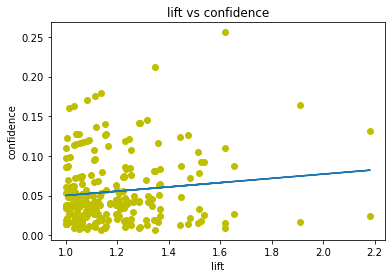

In [60]:
plot_metrics_relationship(apriori_rule_lift, col1='lift', col2='confidence')

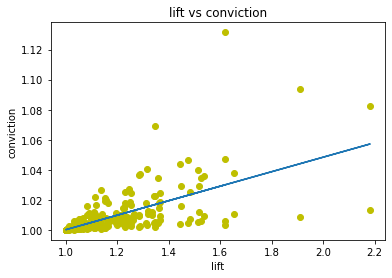

In [61]:
plot_metrics_relationship(apriori_rule_lift, col1='lift', col2='conviction')

# Alteratif: 1. Yaygın öğeler/sık satılan ürünler (frequent itemsets problem) problemini çözen bir Brute-Force yaklaşımı geliştiriniz. 

In [96]:
def frequent_items_brute_force(dataset, min_support):
    # Create an empty dictionary to store the counts of each item
    item_counts = {}
    # Iterate over the dataset
    for transaction in dataset:
        # Iterate over the items in the transaction
        for item in transaction:
            # If the item is not in the dictionary, add it with a count of 1
            if item not in item_counts:
                item_counts[item] = 1
            # If the item is already in the dictionary, increment its count
            else:
                item_counts[item] += 1
    # Create an empty list to store the frequent items
    frequent_items = []
    # Iterate over the item counts
    for item, count in item_counts.items():
        # If the count is greater than or equal to the minimum support
        if count >= min_support:
            # Add the item to the list of frequent items
            frequent_items.append(item)
    # Return the list of frequent items
    return frequent_items
